# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [5]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import wandb

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

### Login to W&B

In [ ]:
wandb.login()

True

### Importing the dataset

In [7]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [8]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [10]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Building the Nerual Network**

### Initializing the ANN

In [13]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

### Adding the second hidden layer

In [15]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [16]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

### Handling Class Imbalance

In this step, we address the class imbalance problem by applying **class weights** technique:

We calculate class weights to give higher importance to the minority class (churn), ensuring the model doesn't ignore churn customers.

it will help improve recall for the churn class.


In [17]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights: ", class_weight_dict)

Class Weights:  {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint

In [19]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking with Weights & Biases (W&B)

In this step, we initialize **Weights & Biases (W&B)** to track and manage our experiment.  
W&B enables systematic logging of hyperparameters, training metrics, and model performance, allowing structured comparison between different model versions within our team.

Each run is assigned a unique `model_id` and descriptive run name to ensure clear experiment versioning.  
Key hyperparameters such as architecture, learning rate, batch size, optimizer, and loss function are stored in the configuration for reproducibility.

By integrating the `WandbMetricsLogger` callback, all training and validation metrics (loss, accuracy, precision, recall, AUC) are automatically logged and visualized in the W&B dashboard.

This setup ensures organized experiment tracking, reproducibility, and collaborative analysis.


In [20]:
RUN_NAME = "model_2_exp_0"

wandb.init(
    entity="arminfakhar1384-",
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 2,
        "architecture": "6-6-relu + sigmoid",
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "class_weight": "balanced"
    }
)

wandb_callback = WandbMetricsLogger()

### Training the ANN on the Training set

In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=wandb.config.epochs,
    batch_size=wandb.config.batch_size,
    class_weight=class_weight_dict,  # Using class weights
    callbacks=[checkpoint, wandb_callback],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4560 - auc: 0.5937 - loss: 0.6805 - precision: 0.2309 - recall: 0.7403 - val_accuracy: 0.5181 - val_auc: 0.6663 - val_loss: 0.6656 - val_precision: 0.2604 - val_recall: 0.7656
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5408 - auc: 0.6690 - loss: 0.6532 - precision: 0.2695 - recall: 0.7283 - val_accuracy: 0.6356 - val_auc: 0.7074 - val_loss: 0.6235 - val_precision: 0.3124 - val_recall: 0.6844
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6506 - auc: 0.7138 - loss: 0.6270 - precision: 0.3364 - recall: 0.6958 - val_accuracy: 0.6581 - val_auc: 0.7320 - val_loss: 0.6059 - val_precision: 0.3283 - val_recall: 0.6781
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6834 - auc: 0.7474 - loss: 0.5893 - precision: 0.3521 - recall: 0.6931 - val_accuracy: 0.6938 - val_auc: 0.7422 - val_loss: 0.5854 - val_precision: 0.3574 - val_recall: 0.6656
Epoch 5/100
200/200 ━━━━

### Performance Visualization - Training and Validation Curves

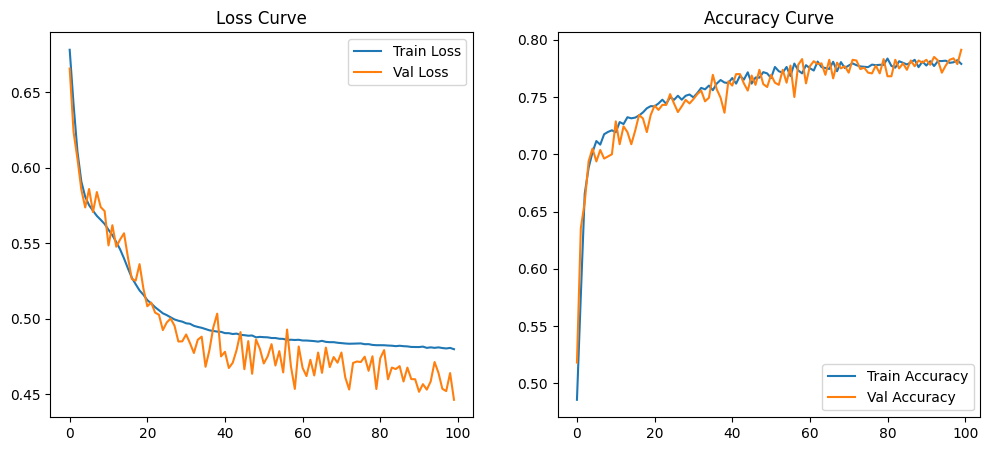

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

## **Predicting and evaluating the model**

### Confusion Matrix Analysis

In [23]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[1267  326]
 [ 110  297]]


**Performance metrics** 

In [24]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.45989131927490234, 0.7820000052452087, 0.4767255187034607, 0.7297297120094299, 0.8484146595001221]

Classification Report:

              precision    recall  f1-score   support

           0     0.9201    0.7954    0.8532      1593
           1     0.4767    0.7297    0.5767       407

    accuracy                         0.7820      2000
   macro avg     0.6984    0.7625    0.7149      2000
weighted avg     0.8299    0.7820    0.7969      2000

ROC-AUC: 0.8483784246496111


### Plotting ROC Curve

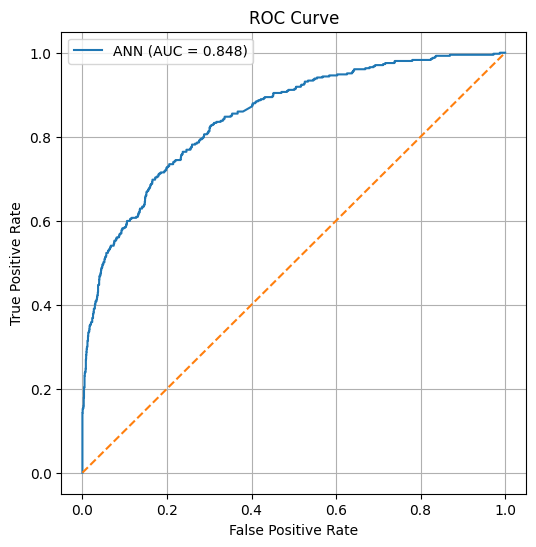

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Impact of Applying Class Weights

After introducing class weighting to address class imbalance, the model's behavior changed significantly.

### Recall Improvement

The recall for the churn class (Class 1) increased substantially to approximately **0.75**, compared to the previous baseline where recall was much lower.

This indicates that the model is now successfully identifying a much larger proportion of actual churned customers, significantly reducing False Negatives.

Since churn prediction prioritizes detecting at-risk customers, this improvement is strategically important.


### Precision Trade-off

However, this improvement came at the cost of lower precision for the churn class (≈ 0.46).

This means the model now produces more False Positives, as it predicts churn more aggressively due to the higher penalty assigned to misclassifying minority samples.

This behavior reflects the natural trade-off between precision and recall when handling imbalanced datasets.


### Macro F1-Score Analysis

The **Macro F1-score (~0.70)** provides a balanced view of performance across both classes, treating them equally regardless of their frequency.

The increase in macro recall (≈ 0.76) demonstrates improved sensitivity toward the minority class.

However, the moderate macro F1-score indicates that although recall improved, precision degradation limits overall balance between classes.


### Overall Conclusion

In summary, class weighting improved minority detection but introduced a precision-recall imbalance. Further tuning (e.g., threshold adjustment or regularization) is required to achieve a better balance between recall and precision.
